In [1]:
!pip install -q transformers accelerate sentencepiece yfinance finnhub-python

In [2]:
import os
import re
import time
import math
import datetime as dt
from typing import List, Dict

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import finnhub

plt.rcParams["figure.figsize"] = (10, 6)

BACKTEST_START = "2024-12-01"
BACKTEST_END   = "2025-11-30"

MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

FINNHUB_API_KEY = "d4tbo91r01qnn6ljv330d4tbo91r01qnn6ljv33g"
finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)

Using device: cuda


In [3]:
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
sp500 = pd.read_csv(url)

tickers = sp500["Symbol"].tolist()

tickers = tickers[:30]

print("Total tickers used:", len(tickers))
tickers[:10]

Total tickers used: 30


['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

In [7]:
all_symbols = tickers + ["SPY"]

raw = yf.download(
    tickers=all_symbols,
    start=BACKTEST_START,
    end=BACKTEST_END,
    auto_adjust=True
)

price_data = raw["Close"]

price_data = price_data.ffill().dropna(how="all")

returns = price_data.pct_change().dropna()

sp500_ret = returns["SPY"]
asset_ret = returns.drop(columns=["SPY"])

asset_ret.head()

[*********************100%***********************]  31 of 31 completed


Ticker,A,ABBV,ABNB,ABT,ACN,ADBE,AEE,AEP,AES,AFL,...,AOS,APD,ARE,AWK,AXP,GOOG,GOOGL,LNT,MMM,MO
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-03,-0.002149,-0.001485,-0.000218,-0.004452,-0.024462,0.000116,-0.011628,-0.012218,0.003075,-0.041652,...,-0.008439,-0.014838,-0.015315,-0.011062,-0.000496,0.000231,-0.000875,-0.007225,-0.013094,-0.004897
2024-12-04,0.006605,-0.027769,0.011713,-0.002752,0.021246,0.039186,0.006863,-0.007936,0.029119,0.002154,...,-0.005674,-0.009557,-0.028606,-0.023043,0.001622,0.017744,0.017684,-0.000809,-0.005337,-0.007909
2024-12-05,-0.016619,-0.001643,-0.019774,-0.003277,-0.005277,0.003225,-0.001623,0.012467,-0.010424,0.007104,...,-0.017391,-0.016825,0.004765,0.008320,-0.006841,-0.010108,-0.009921,-0.003885,0.022077,0.008149
2024-12-06,0.019656,0.000114,0.004401,0.000086,0.012761,0.027387,-0.005310,-0.016419,-0.018059,-0.004084,...,0.004010,-0.005777,-0.014986,0.002044,0.011513,0.012507,0.011990,-0.007800,-0.001650,0.007204
2024-12-09,0.024328,0.002157,0.002556,-0.006055,-0.008823,-0.009097,-0.006755,-0.002817,0.042146,-0.021526,...,0.017628,-0.010903,0.027925,-0.012465,-0.023915,0.004595,0.004928,-0.002457,-0.012170,-0.025471


In [8]:
def fetch_news_for_ticker(ticker, start, end):
    try:
        news = finnhub_client.company_news(ticker, _from=start, to=end)
        df = pd.DataFrame(news)
        if df.empty:
            return df

        # Parse timestamp
        if "datetime" in df.columns:
            df["dt"] = pd.to_datetime(df["datetime"], unit="s")
        else:
            df["dt"] = pd.to_datetime(df["date"], errors="coerce")

        df["date"] = df["dt"].dt.date
        df["ticker"] = ticker

        if "summary" not in df.columns:
            df["summary"] = ""

        return df[["ticker", "date", "headline", "summary"]]

    except Exception as e:
        print("Error for", ticker, ":", e)
        return pd.DataFrame(columns=["ticker", "date", "headline", "summary"])


all_news = []
for i, t in enumerate(tickers):
    print(f"[{i+1}/{len(tickers)}] Fetching news for {t}...")
    df = fetch_news_for_ticker(t, BACKTEST_START, BACKTEST_END)
    all_news.append(df)
    time.sleep(0.3)

news_df = pd.concat(all_news, ignore_index=True)
print("News raw shape:", news_df.shape)
news_df.head()

grouped_news = (
    news_df.groupby(["ticker", "date"])
    .apply(lambda x: "\n".join((x["headline"].fillna("") + " " + x["summary"].fillna(""))))
    .reset_index(name="news_text")
)

print("Grouped news shape:", grouped_news.shape)
grouped_news.head()

[1/30] Fetching news for MMM...
[2/30] Fetching news for AOS...
[3/30] Fetching news for ABT...
[4/30] Fetching news for ABBV...
[5/30] Fetching news for ACN...
[6/30] Fetching news for ADBE...
[7/30] Fetching news for AMD...
[8/30] Fetching news for AES...
[9/30] Fetching news for AFL...
[10/30] Fetching news for A...
[11/30] Fetching news for APD...
[12/30] Fetching news for ABNB...
[13/30] Fetching news for AKAM...
[14/30] Fetching news for ALB...
[15/30] Fetching news for ARE...
[16/30] Fetching news for ALGN...
[17/30] Fetching news for ALLE...
[18/30] Fetching news for LNT...
[19/30] Fetching news for ALL...
[20/30] Fetching news for GOOGL...
[21/30] Fetching news for GOOG...
[22/30] Fetching news for MO...
[23/30] Fetching news for AMZN...
[24/30] Fetching news for AMCR...
[25/30] Fetching news for AEE...
[26/30] Fetching news for AEP...
[27/30] Fetching news for AXP...
[28/30] Fetching news for AIG...
[29/30] Fetching news for AMT...
[30/30] Fetching news for AWK...
News raw sh

/tmp/ipython-input-4079229906.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: "\n".join((x["headline"].fillna("") + " " + x["summary"].fillna(""))))


,ticker,date,news_text
0,A,2025-06-30,From Agilent to ZEISS: SDi's 2025 Report Disse...
1,A,2025-07-01,"Enablement, Anticipation, And Claim Strategy: ..."
2,A,2025-07-06,Spectris: Takeover Highlights Hidden Value In ...
3,A,2025-07-07,Do Options Traders Know Something About Agilen...
4,A,2025-07-08,Liquid Handling Systems Market Insights Report...


In [9]:
from huggingface_hub import login
login()


In [10]:
from huggingface_hub import whoami
whoami()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'type': 'user',
 'id': '690fd818c770065d983f04ef',
 'name': 'ChuoruoL',
 'fullname': 'Chuoruo Lei',
 'email': '15922961977@163.com',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1767225600,
 'isPro': False,
 'avatarUrl': '/avatars/eb22ad3d79357d634c6b9ff6470701eb.svg',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'hw3',
   'role': 'write',
   'createdAt': '2025-12-11T13:18:38.494Z'}}}

In [11]:
MODEL_NAME = "meta-llama/Meta-Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_auth_token=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    use_auth_token=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Llama 3.1 loaded successfully!")


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/tokenization_auto.py:1041: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/auto_factory.py:492: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


...

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Llama 3.1 loaded successfully!


In [12]:
SYSTEM_PROMPT = """
You are a professional equity analyst.
Given recent news for a US stock, write:

[Positive Developments]
...

[Potential Concerns]
...

[Prediction & Analysis]
- One-sentence directional view for next 5 trading days.
- Numeric expected return in % in the exact format:
  EXPECTED_RETURN: +2.5%
"""

def build_prompt(ticker, date, news):
    return f"<s>[SYSTEM]\n{SYSTEM_PROMPT}\n[/SYSTEM]\n[USER]\nTicker: {ticker}\nDate: {date}\nNews:\n{news}\n[/USER]\n[ASSISTANT]\n"

def parse_expected_return(text):
    m = re.search(r"EXPECTED_RETURN:\s*([+-]?\d+(\.\d+)?)%", text)
    if m:
        return float(m.group(1))
    return 0.0


MAX_ROWS = 120
subset_news = grouped_news.head(MAX_ROWS)

results = []

for idx, row in subset_news.iterrows():
    tkr = row["ticker"]
    d   = row["date"]
    news = row["news_text"]

    prompt = build_prompt(tkr, d, news)
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.7,
            top_p=0.9
        )
    text = tokenizer.decode(out[0], skip_special_tokens=True)

    pred = parse_expected_return(text)

    results.append({
        "date": pd.to_datetime(d),
        "ticker": tkr,
        "pred": pred
    })

pred_df = pd.DataFrame(results)
pred_df.head()


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

,date,ticker,pred
0,2025-06-30,A,2.5
1,2025-07-01,A,2.5
2,2025-07-06,A,2.5
3,2025-07-07,A,2.5
4,2025-07-08,A,2.5


In [13]:
pivot_pred = pred_df.pivot(index="date", columns="ticker", values="pred").sort_index()
pred_factor = pivot_pred / 100.0

asset_ret_sub = asset_ret.loc[pred_factor.index.intersection(asset_ret.index)]
pred_factor = pred_factor.loc[asset_ret_sub.index]

def build_signal(pred, mode="long_only"):
    sig = pd.DataFrame(0, index=pred.index, columns=pred.columns)
    if mode == "long_only":
        sig[pred > 0] = 1
    else:
        sig[pred > 0] = 1
        sig[pred < 0] = -1
    return sig

sig_lo = build_signal(pred_factor, "long_only")
sig_ls = build_signal(pred_factor, "long_short")

future_ret = asset_ret_sub.shift(-1).loc[pred_factor.index]

def backtest(sig, fut):
    weight = sig.div((sig != 0).sum(axis=1), axis=0).fillna(0)
    return (weight * fut).sum(axis=1).fillna(0)

ret_lo = backtest(sig_lo, future_ret)
ret_ls = backtest(sig_ls, future_ret)
ret_spy = sp500_ret.loc[ret_lo.index].fillna(0)

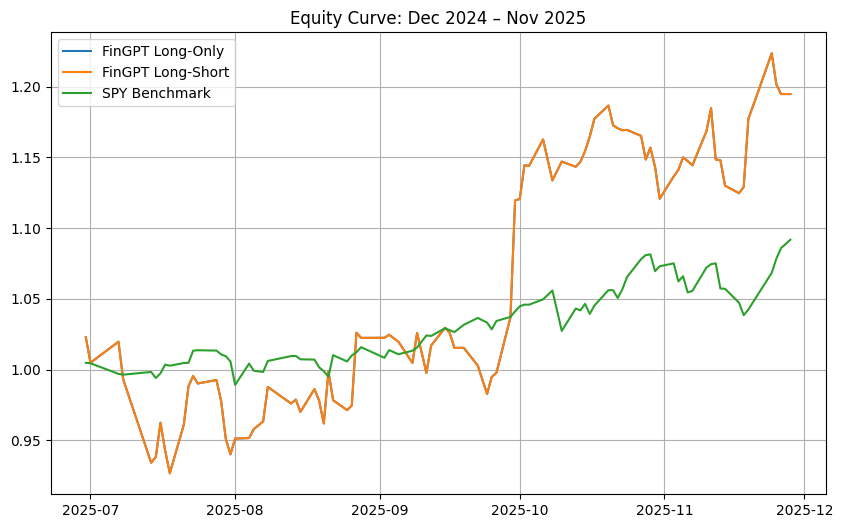

,AnnualReturn,Volatility,Sharpe,MaxDrawdown
FinGPT-LongOnly,0.726305,0.31286,2.321498,-0.093945
FinGPT-LongShort,0.726305,0.31286,2.321498,-0.093945
SPY,0.286853,0.11334,2.530904,-0.039730


In [14]:
def equity(ret):
    return (1 + ret).cumprod()

plt.plot(equity(ret_lo), label="FinGPT Long-Only")
plt.plot(equity(ret_ls), label="FinGPT Long-Short")
plt.plot(equity(ret_spy), label="SPY Benchmark")
plt.legend(); plt.grid()
plt.title("Equity Curve: Dec 2024 – Nov 2025")
plt.show()

def perf_stats(ret):
    ann = (1 + ret.mean())**252 - 1
    vol = ret.std() * np.sqrt(252)
    sharpe = ann / vol if vol > 0 else 0
    dd = (equity(ret)/equity(ret).cummax() - 1).min()
    return {"AnnualReturn": ann, "Volatility": vol, "Sharpe": sharpe, "MaxDrawdown": dd}

result_df = pd.DataFrame([
    perf_stats(ret_lo),
    perf_stats(ret_ls),
    perf_stats(ret_spy)
], index=["FinGPT-LongOnly", "FinGPT-LongShort", "SPY"])

result_df
